In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def make_data(m, n, sigma=0.5, seed=42):
    rng = np.random.default_rng(seed)
    A = rng.standard_normal((m, n))
    w_true = rng.standard_normal(n)
    noise = rng.standard_normal(m) * sigma
    b = A @ w_true + noise
    return A, b

def L_lipschitz(A):
    smax = np.linalg.svd(A, compute_uv=False)[0]
    return 2.0 * (smax**2)

def subgrad_descent_generic(A, b, x0, iters, f_fun, g_fun, schedule, *sched_args):
    x = x0.copy()
    vals = []
    for k in range(iters):
        vals.append(float(f_fun(A, b, x)))
        g = g_fun(A, b, x)
        t = schedule(k, *sched_args)
        x = x - t * g
    vals.append(float(f_fun(A, b, x)))
    return x, np.array(vals)

def adagrad_
(A, b, x0, iters, f_fun, g_fun, eta=1.0, eps=1e-8):
    x = x0.copy()
    G = np.zeros_like(x)
    vals = []
    for _ in range(iters):
        vals.append(float(f_fun(A, b, x)))
        g = g_fun(A, b, x)
        G += g * g
        x = x - eta * g / np.sqrt(G + eps)
    vals.append(float(f_fun(A, b, x)))
    return x, np.array(vals)

# -------- step-size schedules --------
def tau_sqrt(k, tau0):        # tau_k = tau0 / sqrt(k+1)
    return tau0 / np.sqrt(k + 1.0)

def tau_const_T(k, tau0, T):  # tau_k = tau0 / sqrt(T+1)  (constant wrt k)
    return tau0 / np.sqrt(T + 1.0)

def tau_harmonic(k, tau0):    # tau_k = tau0 / (k+1)
    return tau0 / (k + 1.0)

def tau_strong(k, mu):        # tau_k = 1/(mu*(k+1))  (for strong convexity)
    return 1.0 / (mu * (k + 1.0))

# -------- rough tuning (generic) --------
def rough_tune_tau0_generic(A, b, x0, f_fun, g_fun, iters_try=200, cands=(3.0,1.0,0.3,0.1)):
    best, best_val = None, np.inf
    for tau0 in cands:
        _, vals = subgrad_descent_generic(A, b, x0, iters_try, f_fun, g_fun, tau_sqrt, tau0)
        if vals[-1] < best_val:
            best, best_val = tau0, vals[-1]
    return best if best is not None else 1.0

def rough_tune_eta_generic(A, b, x0, f_fun, g_fun, iters_try=200, cands=(3.0,1.0,0.3,0.1)):
    best, best_val = None, np.inf
    for eta in cands:
        _, vals = adagrad_generic(A, b, x0, iters_try, f_fun, g_fun, eta=eta)
        if vals[-1] < best_val:
            best, best_val = eta, vals[-1]
    return best if best is not None else 1.0

# -------- CVX helpers (optional) --------
def solve_star_l1(A, b, lam=0.1):
    """min ||Ax-b||_2 + lam*||x||_1"""
    try:
        import cvxpy as cp
        n = A.shape[1]
        x = cp.Variable(n)
        obj = cp.norm(A @ x - b, 2) + lam * cp.norm1(x)
        prob = cp.Problem(cp.Minimize(obj))
        prob.solve(solver=cp.ECOS, verbose=False)
        if x.value is None: return None, None
        return np.array(x.value).reshape(-1), float(obj.value)
    except Exception:
        return None, None

def solve_star_l2sq(A, b, lam=0.1):
    """min ||Ax-b||_2 + (lam/2)||x||_2^2"""
    try:
        import cvxpy as cp
        n = A.shape[1]
        x = cp.Variable(n)
        obj = cp.norm(A @ x - b, 2) + 0.5*lam*cp.sum_squares(x)
        prob = cp.Problem(cp.Minimize(obj))
        prob.solve(solver=cp.ECOS, verbose=False)
        if x.value is None: return None, None
        return np.array(x.value).reshape(-1), float(obj.value)
    except Exception:
        return None, None


Q5

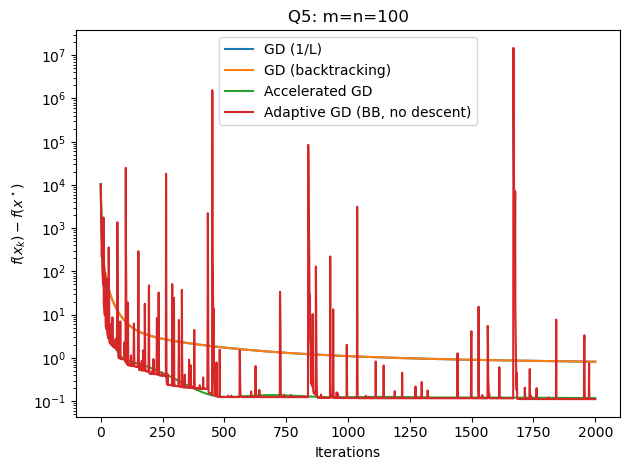

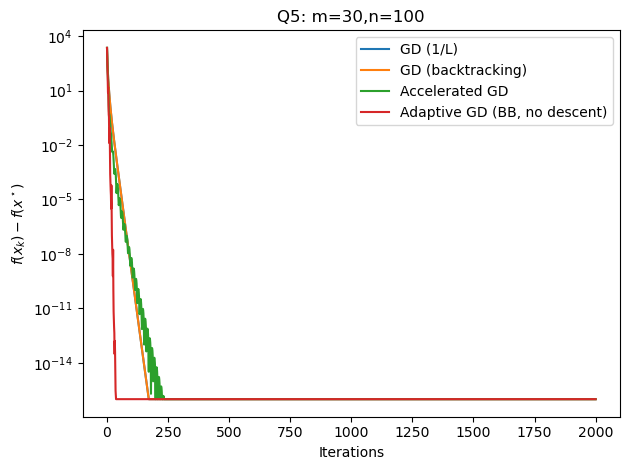

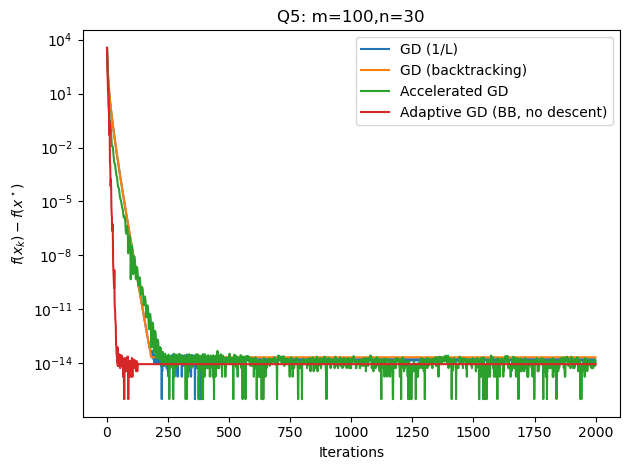

In [3]:
# ----- least-squares objective for Q5 -----
def f_ls(A, b, x):
    r = A @ x - b
    return float(r @ r)

def g_ls(A, b, x):
    r = A @ x - b
    return 2 * (A.T @ r)

# ----- GD, BT, AGD, BB1 -----
def gd_constant(A, b, x0, iters):
    L = L_lipschitz(A)
    t = 1.0 / L
    x = x0.copy(); vals = []
    for _ in range(iters):
        vals.append(f_ls(A,b,x))
        x -= t * g_ls(A,b,x)
    vals.append(f_ls(A,b,x))
    return x, np.array(vals)

def gd_backtracking(A, b, x0, iters, t0=None, beta=0.8, c=1e-4):
    if t0 is None: t0 = 1.0 / L_lipschitz(A)
    x = x0.copy(); vals = []
    for _ in range(iters):
        fx = f_ls(A,b,x); vals.append(fx)
        g = g_ls(A,b,x); t = t0; g2 = float(g @ g)
        while True:
            x_new = x - t * g
            if f_ls(A,b,x_new) <= fx - c*t*g2: break
            t *= beta
        x = x_new
    vals.append(f_ls(A,b,x))
    return x, np.array(vals)

def accel_gd(A, b, x0, iters):
    L = L_lipschitz(A); t = 1.0 / L
    x = x0.copy(); y = x0.copy(); vals = []
    for k in range(1, iters+1):
        vals.append(f_ls(A,b,x))
        g = g_ls(A,b,y)
        x_next = y - t*g
        theta = (k-1)/(k+2)
        y = x_next + theta*(x_next - x)
        x = x_next
    vals.append(f_ls(A,b,x))
    return x, np.array(vals)

def gd_bb(A, b, x0, iters, alpha0=None, clip=(1e-12,1e12)):
    if alpha0 is None: alpha0 = 1.0 / L_lipschitz(A)
    x_prev = x0.copy(); g_prev = g_ls(A,b,x_prev); alpha = alpha0
    x = x_prev - alpha*g_prev; vals = [f_ls(A,b,x_prev)]
    for _ in range(1, iters):
        vals.append(f_ls(A,b,x))
        g = g_ls(A,b,x); s = x - x_prev; y = g - g_prev
        sty = float(s @ y); sts = float(s @ s)
        if abs(sty) > 0: alpha = sts / max(sty, 1e-30)
        alpha = float(np.clip(alpha, *clip))
        x_next = x - alpha*g
        x_prev, x = x, x_next; g_prev = g
    vals.append(f_ls(A,b,x))
    return x, np.array(vals)

def run_and_plot_q5(m, n, iters=2000, seed=42, title=""):
    A, b = make_data(m,n,seed=seed)
    x0 = np.zeros(n)
    # exact LS minimizer
    x_star, *_ = np.linalg.lstsq(A, b, rcond=None)
    f_star = f_ls(A, b, x_star)

    _, v_gd  = gd_constant(A, b, x0, iters)
    _, v_bt  = gd_backtracking(A, b, x0, iters)
    _, v_agd = accel_gd(A, b, x0, iters)
    _, v_bb  = gd_bb(A, b, x0, iters)

    plt.figure()
    for label, vals in {
        "GD (1/L)": v_gd,
        "GD (backtracking)": v_bt,
        "Accelerated GD": v_agd,
        "Adaptive GD (BB, no descent)": v_bb,
    }.items():
        gap = np.maximum(vals - f_star, 1e-16)
        plt.semilogy(gap, label=label)
    plt.xlabel("Iterations"); plt.ylabel(r"$f(x_k)-f(x^\star)$")
    plt.title(title or f"m={m}, n={n}"); plt.legend(); plt.tight_layout(); plt.show()

# examples
run_and_plot_q5(100,100,iters=2000,title="Q5: m=n=100")
run_and_plot_q5(30,100, iters=2000,title="Q5: m=30,n=100")
run_and_plot_q5(100,30, iters=2000,title="Q5: m=100,n=30")


Q6

[Q6 tuned] tau0≈0.1, eta≈0.3
[Q6 proxy f*] 9.380538e+00


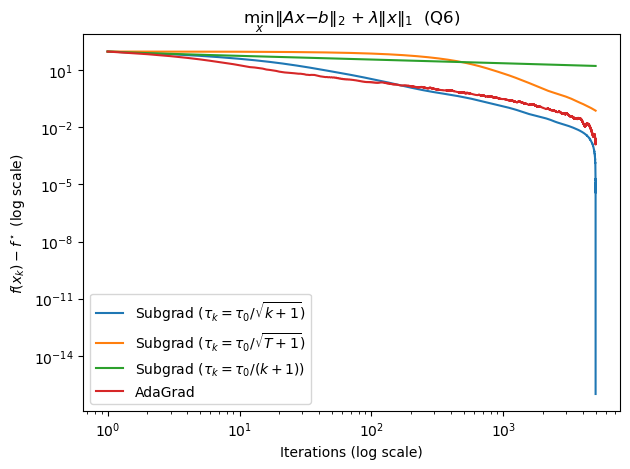

[Q7 tuned] tau0≈0.1, eta≈0.3, mu=0.1
[Q7 proxy f*] 6.517806e+00


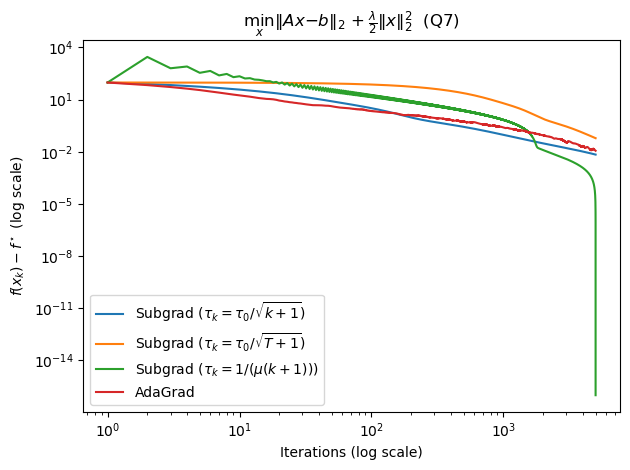

In [4]:
# -------- Q6 objective & subgradient: ||Ax-b||_2 + lam||x||_1 --------
def f_l1(A, b, x, lam=0.1):
    r = A @ x - b
    return float(np.linalg.norm(r,2) + lam*np.linalg.norm(x,1))

def g_l1(A, b, x, lam=0.1):
    r = A @ x - b; nr = np.linalg.norm(r,2)
    u = r/nr if nr>0 else np.zeros_like(r)
    s = np.sign(x)  # sign(0)=0 is a valid subgradient element
    return A.T @ u + lam*s

# -------- Q7 objective & subgradient: ||Ax-b||_2 + (lam/2)||x||_2^2 --------
def f_l2sq(A, b, x, lam=0.1):
    r = A @ x - b
    return float(np.linalg.norm(r,2) + 0.5*lam*np.linalg.norm(x,2)**2)

def g_l2sq(A, b, x, lam=0.1):
    r = A @ x - b; nr = np.linalg.norm(r,2)
    u = r/nr if nr>0 else np.zeros_like(r)
    return A.T @ u + lam*x  # strong convexity mu=lam

# -------- Runners --------
def run_and_plot_q6(m=100,n=100,iters=5000,lam=0.1,seed=42,tune=True):
    A,b = make_data(m,n,seed=seed); x0 = np.zeros(n)
    # tuning
    tau0 = rough_tune_tau0_generic(A,b,x0, lambda A,b,x:f_l1(A,b,x,lam),
                                   lambda A,b,x:g_l1(A,b,x,lam),
                                   iters_try=min(200,iters//10)) if tune else 1.0
    eta  = rough_tune_eta_generic(A,b,x0,  lambda A,b,x:f_l1(A,b,x,lam),
                                   lambda A,b,x:g_l1(A,b,x,lam),
                                   iters_try=min(200,iters//10)) if tune else 1.0
    print(f"[Q6 tuned] tau0≈{tau0}, eta≈{eta}")

    # runs
    _, v_sqrt  = subgrad_descent_generic(A,b,x0,iters, lambda A,b,x:f_l1(A,b,x,lam),
                                         lambda A,b,x:g_l1(A,b,x,lam), tau_sqrt, tau0)
    _, v_const = subgrad_descent_generic(A,b,x0,iters, lambda A,b,x:f_l1(A,b,x,lam),
                                         lambda A,b,x:g_l1(A,b,x,lam), tau_const_T, tau0, iters)
    _, v_harm  = subgrad_descent_generic(A,b,x0,iters, lambda A,b,x:f_l1(A,b,x,lam),
                                         lambda A,b,x:g_l1(A,b,x,lam), tau_harmonic, tau0)
    _, v_ada   = adagrad_generic(A,b,x0,iters,         lambda A,b,x:f_l1(A,b,x,lam),
                                         lambda A,b,x:g_l1(A,b,x,lam), eta=eta)

    # f*
    _, f_star = solve_star_l1(A,b,lam)
    if f_star is None:
        f_star = min(v_sqrt.min(),v_const.min(),v_harm.min(),v_ada.min())
        print(f"[Q6 proxy f*] {f_star:.6e}")

    # log-log
    plt.figure()
    curves = {
        r"Subgrad ($\tau_k=\tau_0/\sqrt{k+1}$)": v_sqrt,
        r"Subgrad ($\tau_k=\tau_0/\sqrt{T+1}$)": v_const,
        r"Subgrad ($\tau_k=\tau_0/(k+1)$)":      v_harm,
        r"AdaGrad":                               v_ada,
    }
    for label, vals in curves.items():
        k = np.arange(1,len(vals)+1); gap = np.maximum(vals - f_star, 1e-16)
        plt.loglog(k, gap, label=label)
    plt.xlabel("Iterations (log scale)"); plt.ylabel(r"$f(x_k)-f^\star$ (log scale)")
    plt.title(r"$\min_x \|Ax-b\|_2 + \lambda \|x\|_1$  (Q6)")
    plt.legend(); plt.tight_layout(); plt.show()

def run_and_plot_q7(m=100,n=100,iters=5000,lam=0.1,seed=42,tune=True):
    A,b = make_data(m,n,seed=seed); x0 = np.zeros(n); mu = lam
    # tuning
    tau0 = rough_tune_tau0_generic(A,b,x0, lambda A,b,x:f_l2sq(A,b,x,lam),
                                   lambda A,b,x:g_l2sq(A,b,x,lam),
                                   iters_try=min(200,iters//10)) if tune else 1.0
    eta  = rough_tune_eta_generic(A,b,x0,  lambda A,b,x:f_l2sq(A,b,x,lam),
                                   lambda A,b,x:g_l2sq(A,b,x,lam),
                                   iters_try=min(200,iters//10)) if tune else 1.0
    print(f"[Q7 tuned] tau0≈{tau0}, eta≈{eta}, mu={mu}")

    # runs
    _, v_sqrt  = subgrad_descent_generic(A,b,x0,iters, lambda A,b,x:f_l2sq(A,b,x,lam),
                                         lambda A,b,x:g_l2sq(A,b,x,lam), tau_sqrt, tau0)
    _, v_const = subgrad_descent_generic(A,b,x0,iters, lambda A,b,x:f_l2sq(A,b,x,lam),
                                         lambda A,b,x:g_l2sq(A,b,x,lam), tau_const_T, tau0, iters)
    _, v_mu    = subgrad_descent_generic(A,b,x0,iters, lambda A,b,x:f_l2sq(A,b,x,lam),
                                         lambda A,b,x:g_l2sq(A,b,x,lam), tau_strong, mu)
    _, v_ada   = adagrad_generic(A,b,x0,iters,         lambda A,b,x:f_l2sq(A,b,x,lam),
                                         lambda A,b,x:g_l2sq(A,b,x,lam), eta=eta)

    # f*
    _, f_star = solve_star_l2sq(A,b,lam)
    if f_star is None:
        f_star = min(v_sqrt.min(),v_const.min(),v_mu.min(),v_ada.min())
        print(f"[Q7 proxy f*] {f_star:.6e}")

    # log-log
    plt.figure()
    curves = {
        r"Subgrad ($\tau_k=\tau_0/\sqrt{k+1}$)": v_sqrt,
        r"Subgrad ($\tau_k=\tau_0/\sqrt{T+1}$)": v_const,
        r"Subgrad ($\tau_k=1/(\mu(k+1))$)":     v_mu,
        r"AdaGrad":                               v_ada,
    }
    for label, vals in curves.items():
        k = np.arange(1,len(vals)+1); gap = np.maximum(vals - f_star, 1e-16)
        plt.loglog(k, gap, label=label)
    plt.xlabel("Iterations (log scale)"); plt.ylabel(r"$f(x_k)-f^\star$ (log scale)")
    plt.title(r"$\min_x \|Ax-b\|_2 + \frac{\lambda}{2}\|x\|_2^2$  (Q7)")
    plt.legend(); plt.tight_layout(); plt.show()

# examples
run_and_plot_q6(m=100,n=100,iters=5000,lam=0.1,seed=42,tune=True)
run_and_plot_q7(m=100,n=100,iters=5000,lam=0.1,seed=42,tune=True)


Q7